11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Creating Conditional GAN model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Training Conditional GAN...
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 65s 129ms/step - d_loss: 0.2302 - g_loss: 3.6724
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 60s 128ms/step - d_loss: 0.0711 - g_loss: 4.6994
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 85s 135ms/step - d_loss: 0.0142 - g_loss: 6.0979
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 60s 127ms/step - d_loss: 0.0629 - g_loss: 7.1221
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 130ms/step - d_loss: 0.0124 - g_loss: 6.4292

Generating digits...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step


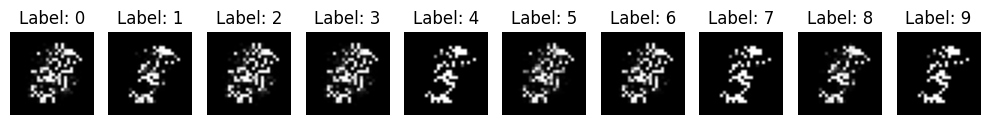

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense, Reshape, Flatten, LeakyReLU, Embedding, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load and preprocess MNIST data (now including labels)
(x_train, y_train), (_, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), 28, 28, 1))

# Network parameters
latent_dim = 100
num_classes = 10
img_shape = (28, 28, 1)
batch_size = 128
epochs = 5  # Reduced epochs for faster training

# [Previous generator and discriminator code remains the same]
def build_generator():
    # Noise input
    noise_input = Input(shape=(latent_dim,))

    # Label input
    label_input = Input(shape=(1,))

    # Embed label
    label_embedding = Embedding(num_classes, 50)(label_input)
    label_embedding = Flatten()(label_embedding)

    # Combine noise and label
    combined_input = Concatenate()([noise_input, label_embedding])

    # Generator network
    x = Dense(256)(combined_input)
    x = LeakyReLU(alpha=0.2)(x)
    x = Dense(512)(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = Dense(1024)(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = Dense(np.prod(img_shape), activation='sigmoid')(x)
    x = img_output = Reshape(img_shape)(x)

    generator = Model([noise_input, label_input], img_output, name='generator')
    return generator

def build_discriminator():
    # Image input
    img_input = Input(shape=img_shape)

    # Label input
    label_input = Input(shape=(1,))

    # Embed label
    label_embedding = Embedding(num_classes, np.prod(img_shape))(label_input)
    label_embedding = Flatten()(label_embedding)
    label_embedding = Reshape(img_shape)(label_embedding)

    # Combine image and label
    combined_input = Concatenate(axis=-1)([img_input, label_embedding])

    # Discriminator network
    x = Flatten()(combined_input)
    x = Dense(512)(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = Dense(256)(x)
    x = LeakyReLU(alpha=0.2)(x)
    validity = Dense(1, activation='sigmoid')(x)

    discriminator = Model([img_input, label_input], validity, name='discriminator')
    return discriminator

class CGAN(tf.keras.Model):
    def __init__(self, discriminator, generator):
        super().__init__()
        self.discriminator = discriminator
        self.generator = generator

        # Track losses
        self.d_loss_tracker = tf.keras.metrics.Mean(name='d_loss')
        self.g_loss_tracker = tf.keras.metrics.Mean(name='g_loss')

    @property
    def metrics(self):
        return [self.d_loss_tracker, self.g_loss_tracker]

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super().compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn

    def train_step(self, data):
        # Unpack the data
        images, labels = data
        batch_size = tf.shape(images)[0]

        # Train discriminator
        noise = tf.random.normal([batch_size, latent_dim])
        generated_images = self.generator([noise, labels])

        with tf.GradientTape() as tape:
            # Real images
            real_output = self.discriminator([images, labels])
            # Fake images
            fake_output = self.discriminator([generated_images, labels])

            # Calculate discriminator loss
            d_loss_real = self.loss_fn(tf.ones_like(real_output), real_output)
            d_loss_fake = self.loss_fn(tf.zeros_like(fake_output), fake_output)
            d_loss = (d_loss_real + d_loss_fake) / 2

        # Update discriminator
        d_grads = tape.gradient(d_loss, self.discriminator.trainable_variables)
        self.d_optimizer.apply_gradients(zip(d_grads, self.discriminator.trainable_variables))

        # Train generator
        noise = tf.random.normal([batch_size, latent_dim])

        with tf.GradientTape() as tape:
            # Generate fake images
            generated_images = self.generator([noise, labels])
            # Get discriminator output
            fake_output = self.discriminator([generated_images, labels])
            # Calculate generator loss
            g_loss = self.loss_fn(tf.ones_like(fake_output), fake_output)

        # Update generator
        g_grads = tape.gradient(g_loss, self.generator.trainable_variables)
        self.g_optimizer.apply_gradients(zip(g_grads, self.generator.trainable_variables))

        # Update metrics
        self.d_loss_tracker.update_state(d_loss)
        self.g_loss_tracker.update_state(g_loss)

        return {
            "d_loss": self.d_loss_tracker.result(),
            "g_loss": self.g_loss_tracker.result()
        }

# Build and compile the CGAN
print("Creating Conditional GAN model...")
discriminator = build_discriminator()
generator = build_generator()

cgan = CGAN(discriminator, generator)
cgan.compile(
    d_optimizer=Adam(learning_rate=0.0002, beta_1=0.5),
    g_optimizer=Adam(learning_rate=0.0002, beta_1=0.5),
    loss_fn=tf.keras.losses.BinaryCrossentropy()
)

# Create the training dataset
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset = train_dataset.shuffle(60000).batch(batch_size)

# Train the CGAN
print("Training Conditional GAN...")
cgan.fit(train_dataset, epochs=epochs)

def generate_digits(generator, digits_to_generate=None):
    """
    Generate digits using the conditional generator
    digits_to_generate: list of digit labels to generate (if None, generates one of each 0-9)
    """
    if digits_to_generate is None:
        digits_to_generate = list(range(10))

    n = len(digits_to_generate)
    noise = tf.random.normal([n, latent_dim])
    labels = np.array(digits_to_generate)
    generated_images = generator.predict([noise, labels])
    return generated_images, labels

# Generate and visualize digits
print("\nGenerating digits...")
new_digits, labels = generate_digits(generator)

plt.figure(figsize=(10, 2))
for i in range(len(new_digits)):
    plt.subplot(1, 10, i + 1)
    plt.imshow(new_digits[i].reshape(28, 28), cmap='gray')
    plt.title(f'Label: {labels[i]}')
    plt.axis('off')
plt.tight_layout()
plt.show()